In [1]:
include("evolMPDO.jl");
include("IsingED.jl");

using GLM
using DataFrames

using Plots

### J1-J2 model

In [132]:
N = 8;
J2 = 0.241167; # 0.241167
J1J2_psiMPS = J1J2_GS_DMRG(N,J2, true,nsweeps=10);
J1J2_GS = myMPS(MPS_to_array(J1J2_psiMPS));

After sweep 1 energy=-3.2927992228880414  maxlinkdim=20 maxerr=2.79E-08 time=0.042
After sweep 2 energy=-3.2929413764938955  maxlinkdim=30 maxerr=9.96E-11 time=0.024
After sweep 3 energy=-3.292941376494991  maxlinkdim=24 maxerr=9.70E-11 time=0.012
After sweep 4 energy=-3.2929413764949937  maxlinkdim=24 maxerr=9.70E-11 time=0.020
After sweep 5 energy=-3.2929413764949906  maxlinkdim=24 maxerr=9.70E-11 time=0.019
After sweep 6 energy=-3.2929413764949897  maxlinkdim=16 maxerr=3.83E-16 time=0.016
After sweep 7 energy=-3.2929413764949924  maxlinkdim=16 maxerr=3.76E-16 time=0.008
After sweep 8 energy=-3.292941376494993  maxlinkdim=16 maxerr=2.66E-16 time=0.009
After sweep 9 energy=-3.2929413764949933  maxlinkdim=16 maxerr=3.65E-16 time=0.012
After sweep 10 energy=-3.2929413764949915  maxlinkdim=16 maxerr=3.26E-16 time=0.008


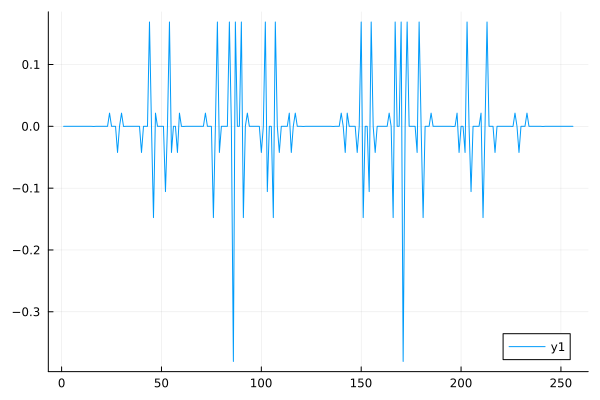

In [127]:
wavefunction = MPS_to_dense(J1J2_GS)
plot(real.(wavefunction))  # examine whether components are positive

### Fidelity

In [136]:
p1 = 1.0;
Ws1 = Array{ComplexF64,3}[purified_dephasing_channel(p1,[0,0,1]) for _ in 1:N]
M1 = add_noise_MPS(J1J2_GS, Ws1)

Sp = [0 1; 0 0]
Sm = [0 0; 1 0]

i = 1
j = 3

M2 = add_CP(M1, Sp, i)
M2 = add_CP(M2, Sm, j)

M2_norm = only(MPDO_norm(M2))

0.19240886105657745 - 4.279019551647438e-17im

In [161]:
F0, rho_dense, rho_op_dense = fidelity_op_debug(M1, Sp, Sm, i, j);
test = diag(rho_dense)
norm(test)
sqrt.(diag(rho_dense))' * sqrt.(diag(rho_op_dense))

0.11518227788684543 + 0.0im

In [166]:
J1J2_GS
AS = add_operator(add_operator(J1J2_GS, Sp,i), Sm, j)
# only(left_environments(J1J2_GS, AS)[end])

myMPS{ComplexF64}(Array{ComplexF64, 3}[[-0.09860948487735062 + 0.12745941854934717im 0.0 + 0.0im;;; 0.20508302786869326 + 0.6572451732766805im 0.0 + 0.0im], [-0.04371125899426395 - 0.18605797538285598im -0.08625207950345468 - 0.8119835300629443im; 0.5446431283154254 - 0.6083753258400085im -0.1442291325485476 + 0.12540415340300523im;;; 0.4290062142033202 - 0.04953817262421864im -0.01018814088567533 + 0.03890046930945958im; -0.029257808921713264 - 0.0935474151304512im 0.008416707104983774 + 0.0038298689383913635im;;; -0.07388575329949819 - 0.016342993599194045im 0.11958885354225997 + 0.2802261408265157im; 0.11108824475035578 - 0.27239649628212925im -0.09282850040200508 - 0.06401634591576974im;;; -0.021058794662600265 + 0.0017165551381960597im 0.09796363076942396 - 0.0im; 0.03596992926631996 - 0.08124455793712206im 0.42411348464856063 - 0.0im], [0.0 + 0.0im -0.6415120349536114 - 0.1822843371790505im; 0.0 + 0.0im 0.07352080559657949 - 0.006274412459727645im; 0.0 + 0.0im 0.49916216317109074

In [179]:
bs = [1,2,2,1,2,2,1,1]
read_component(J1J2_GS, bs)

1×1 Matrix{ComplexF64}:
 0.04227853575659375 - 2.490887285212811e-17im

In [180]:
bs = [2,2,1,1,2,2,1,1]
read_component(J1J2_GS, bs)

1×1 Matrix{ComplexF64}:
 0.10559640427867163 - 7.554645884081253e-17im

In [204]:
v_bits = []
vr_bits = []
for ii in 0:63
    tmp = zeros(Int64, 8)
    tmpr = zeros(Int64, 8)
    tmp2 = digits(UInt(ii), base=2, pad=6)
    tmp[1] = 1
    tmp[3] = 2
    tmp[2] = tmp2[1] + 1
    tmp[4:8] = tmp2[2:6] .+ 1

    tmpr[1] = 2
    tmpr[3] = 1
    tmpr[2] = tmp2[1] + 1
    tmpr[4:8] = tmp2[2:6] .+ 1
    push!(v_bits, tmp)
    push!(vr_bits, tmpr)
end

In [ ]:
for ii in 1:64
    println(ii)
    println(read_component(J1J2_GS, v_bits[ii]))
    println(read_component(J1J2_GS, vr_bits[ii]))
end


ComplexF64[-2.644448302010147e-16 + 6.971677428521545e-17im;;]
ComplexF64[-9.57626434955538e-17 + 1.9866866285662765e-16im;;]


In [ ]:
# F(rho, Sp^i Sm^j rho Sp^j Sm^i)
F0_array = [fidelity_op(M1, Sp, Sm, i, j) for j in 1:N]

8-element Vector{Float64}:
 0.5000000000899325
 0.30218994580296815
 0.11518227789703234
 0.10285958160347047
 0.07973449903084723
 0.10285958160299827
 0.11518227788685492
 0.30218994578571967

In [135]:
# |<psi|Sp^i Sm^j|psi>|
F0_mps_array = [fidelity_op_mps(J1J2_GS, Sp, Sm, i, j) for j in 1:N]

8-element Vector{Float64}:
 0.499999999999999
 0.3021899457857208
 0.11518227788684521
 0.10285958160299591
 0.07973449900374037
 0.10285958160299558
 0.11518227788684496
 0.3021899457857184

In [28]:
fidelity_op_mps(J1J2_GS, Sp, Sm, i, j)

0.12596854749318703

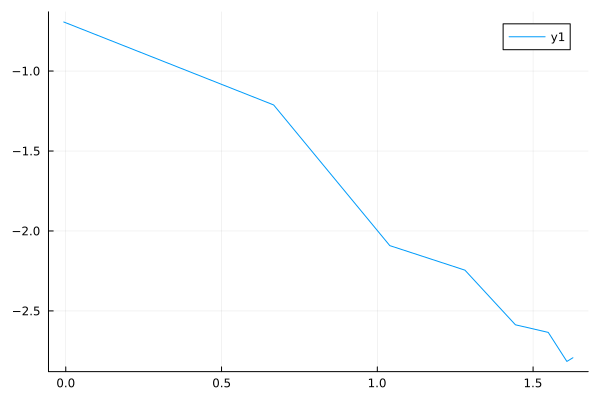

In [120]:
x0 = range(1,N)
entp = Int(N/2)
x0p = N/pi*sin.(pi*x0/N)
plot(log.(x0p[1:entp]), log.(F0_mps_array[1:entp]))

[-0.7517040881607358, -1.2559985844368733]


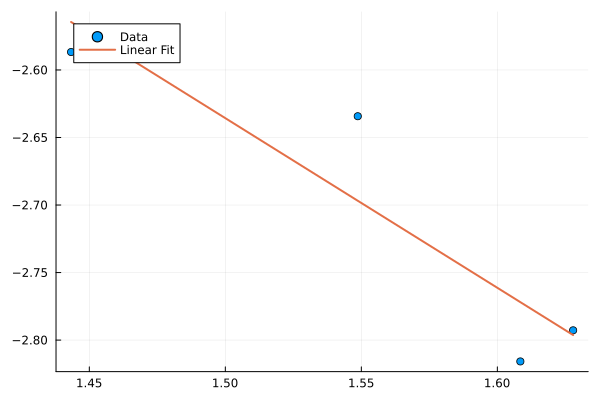

In [121]:
intp = 5
entp = Int(N/2)
x0p = N/pi*sin.(pi*x0/N)
x = log.(x0p[intp:1:entp])
y = log.(F0_mps_array[intp:1:entp])

# Step 1: Put data into a DataFrame
df = DataFrame(x = x, y = y)

# Step 2: Fit linear model y ~ x
model = lm(@formula(y ~ x), df)

# Step 3: Get predicted y values
yp = predict(model)
println(coef(model))

# Step 4: Plot original data and fitted line
scatter(x, y, label = "Data", legend = :topleft)
plot!(x, yp, label = "Linear Fit", lw=2)

### MPDO fidelity

In [117]:
function random_U(d::Int, dt::Float64, N::Int)
    # without ancilla d=2, with ancilla d=4
    Us = Matrix[]
    for i in 1:2*N-3
        H = randn(d*d,d*d) + 1im*randn(d*d,d*d)
        H = (H+H')/2
        push!(Us, exp(im*dt*H))
    end
    return Us
end

random_U (generic function with 1 method)

In [118]:
d = 2   
dt = 1.0;
Us_down = random_U(d, dt, N)
Us_up = random_U(d, dt, N)
# ovs = optimize_overlap_real_nfloor_sweep(complex(M1), complex(M2), [Us_down, Us_up],100,verbose=1);
ovs = optimize_overlap_real_nfloor_sweep(complex(M1), complex(M2), [Us_down],20,verbose=1);
# ovs = optimize_overlap_real_nfloor_sweep(complex(M1), complex(M2), [Us_down, Us_up],30,verbose=1);

Sweep: 1
New overlap: 0.19670152289611856
Max bond dim: 230
New overlap: 0.26616496519574173
Max bond dim: 315
Sweep: 2
New overlap: 0.278762493234582
Max bond dim: 192
New overlap: 0.28236689964151196
Max bond dim: 267
Sweep: 3
New overlap: 0.28369174009996306
Max bond dim: 168
New overlap: 0.28422201488161536
Max bond dim: 233
Sweep: 4
New overlap: 0.2844401718962114
Max bond dim: 148
New overlap: 0.2845309213471618
Max bond dim: 201
Sweep: 5
New overlap: 0.2845688879840846
Max bond dim: 130
New overlap: 0.2845848372702485
Max bond dim: 177
Sweep: 6
New overlap: 0.28459155632386224
Max bond dim: 115
New overlap: 0.28459439575413326
Max bond dim: 159
Sweep: 7
New overlap: 0.2845955967210445
Max bond dim: 103
New overlap: 0.2845961071238441
Max bond dim: 138
Sweep: 8
New overlap: 0.2845963229034111
Max bond dim: 94
New overlap: 0.2845964157065995
Max bond dim: 123
Sweep: 9
New overlap: 0.2845964542106893
Max bond dim: 85
New overlap: 0.2845964716389521
Max bond dim: 112
Sweep: 10
New o

1200-element Vector{Float64}:
 0.0002706553085601412
 0.0006905145732855875
 0.0010268530957322393
 0.0015449247478379025
 0.00192343450525242
 0.0028894383548561118
 0.0035327250345155697
 0.004764168250891785
 0.009183309830340889
 0.011603788803597723
 ⋮
 0.2845964837845963
 0.28459648393124154
 0.2845964839539258
 0.28459648397410164
 0.28459648398068454
 0.2845964839931927
 0.2845964839932083
 0.28459648399320836
 0.28459648399320836

In [90]:
ovs = optimize_overlap_twofloor_sweep(complex(M1), complex(M2),Us_down,3,verbose=1)

Initial overlap: 1.5759897783315636e-33
Sweep: 1
New overlap: 0.2784911819111103
Max bond dim: 32
New overlap: 0.30011816649655787
Max bond dim: 64
Sweep: 2
New overlap: 0.3031303038314433
Max bond dim: 27
New overlap: 0.30357038657886926
Max bond dim: 56
Sweep: 3
New overlap: 0.3036448097527781
Max bond dim: 21
New overlap: 0.30365884592959536
Max bond dim: 42
Final norm: ComplexF64[1.0000000000000016 + 1.5654093289890675e-16im;;]


84-element Vector{Float64}:
 0.0062477098264271756
 0.011729483140429412
 0.016362065859738567
 0.025645191608090288
 0.035424738739318305
 0.05466695352074426
 0.11961114207119294
 0.21146422474337798
 0.22114554256812335
 0.23913058279641156
 ⋮
 0.3036455551286952
 0.3036543704888801
 0.30365451635438534
 0.3036545561985999
 0.3036582241542137
 0.30365846931785384
 0.3036585260654505
 0.3036586145097969
 0.30365884592959536

In [119]:
0.28459648399320836 * sqrt(M2_norm)

0.12348291579241703 + 0.0im